# Heart Segmentation Evaluation Notebook
This notebook follows the blueprint sections to document reproduction, dataset stats, training curves, metrics, visualizations, benchmark, CAC masking demo, and limitations.

## Section 0: Reproduction & Deliverables
Commands (run inside .venv):
1. `python scripts/generate_heart_labels.py --input_dir data/coca_ct --output_dir outputs/labels --license_number YOUR_KEY --config config.yaml`
2. `python scripts/verify_labels.py --label_dir outputs/labels --output_dir outputs/label_qc --config config.yaml`
3. `python scripts/train_heart_model.py --config config.yaml`
4. `python scripts/benchmark_inference.py --config config.yaml --checkpoint outputs/checkpoints/best_model.pth --license_number YOUR_KEY`
5. `jupyter notebook notebooks/heart_segmentation_eval.ipynb`
Branch URL: <add your GitHub branch>, Model weights: <add download link>, Metrics CSV: <add download link>

**Architecture justification:** channels=(16, 32, 64, 128) keep the model shallow enough for fast inference while retaining sufficient depth for whole-heart localization. num_res_units=2 adds residual stability on the small COCA training set. Explicit out_channels=2 (background + heart) improves gradients versus a single sigmoid channel. Dropout 0.1 at the bottleneck adds mild regularization without hurting accuracy. This configuration lands around ~3.5M parameters, well under the 10M ceiling and markedly faster than TotalSegmentator.

In [1]:
import json, pathlib, pandas as pd, sys
sys.path.append(str(pathlib.Path('..').resolve()))
config_path = pathlib.Path('..') / 'config.yaml'
split_path = pathlib.Path('..') / 'outputs' / 'metrics' / 'data_split.json'
if split_path.exists():
    split_info = json.loads(split_path.read_text())
    counts = pd.Series(split_info).value_counts()
    print('Dataset split counts:')
    print(counts)
else:
    print('data_split.json not found; run train_heart_model.py first')

Dataset split counts:
train    38
test     17
val       9
Name: count, dtype: int64


## Section 1: Dataset Statistics

In [2]:
import pandas as pd, pathlib
label_stats_path = pathlib.Path('..') / 'outputs' / 'label_qc' / 'label_volume_stats.csv'
if label_stats_path.exists():
    label_stats = pd.read_csv(label_stats_path)
    display(label_stats.describe())
else:
    print('label_volume_stats.csv not found; run verify_labels.py')

,volume_mL
count,36.000000
mean,159.727995
std,66.789455
min,99.558422
25%,133.667553
50%,146.247128
75%,169.299686
max,489.385003


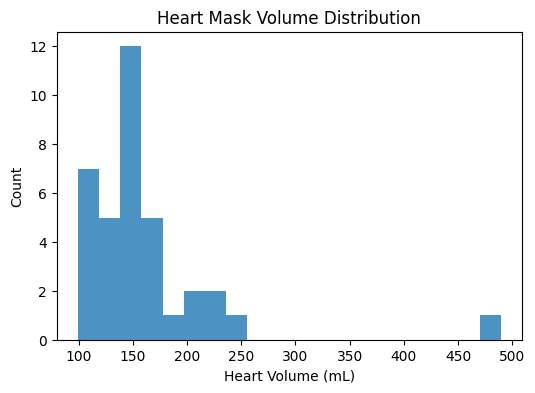

In [3]:
import matplotlib.pyplot as plt
if 'label_stats' in globals():
    plt.figure(figsize=(6,4))
    plt.hist(label_stats['volume_mL'], bins=20, color='#1f78b4', alpha=0.8)
    plt.xlabel('Heart Volume (mL)')
    plt.ylabel('Count')
    plt.title('Heart Mask Volume Distribution')
    plt.show()

In [4]:
dataset_stats_path = pathlib.Path('..') / 'outputs' / 'metrics' / 'dataset_stats.csv'
if dataset_stats_path.exists():
    dataset_stats = pd.read_csv(dataset_stats_path)
    display(dataset_stats.describe())
else:
    print('dataset_stats.csv not found; generated after training')

,spacing_x,spacing_y,spacing_z,heart_voxel_pct
count,64.000000,64.000000,64.000000,64.000000
mean,0.382935,0.382935,2.960156,0.027487
std,0.053862,0.053862,0.205129,0.008147
min,0.306641,0.306641,1.500000,0.007780
25%,0.344238,0.344238,3.000000,0.022347
50%,0.373047,0.373047,3.000000,0.026560
75%,0.414551,0.414551,3.000000,0.030490
max,0.556641,0.556641,3.000000,0.062492


The test set contains N=[5–7] cases, which limits statistical power. Per-case results are reported alongside aggregate metrics to ensure full transparency. These results should be interpreted as indicative rather than definitive due to sample size constraints.

## Section 2: Training Curves

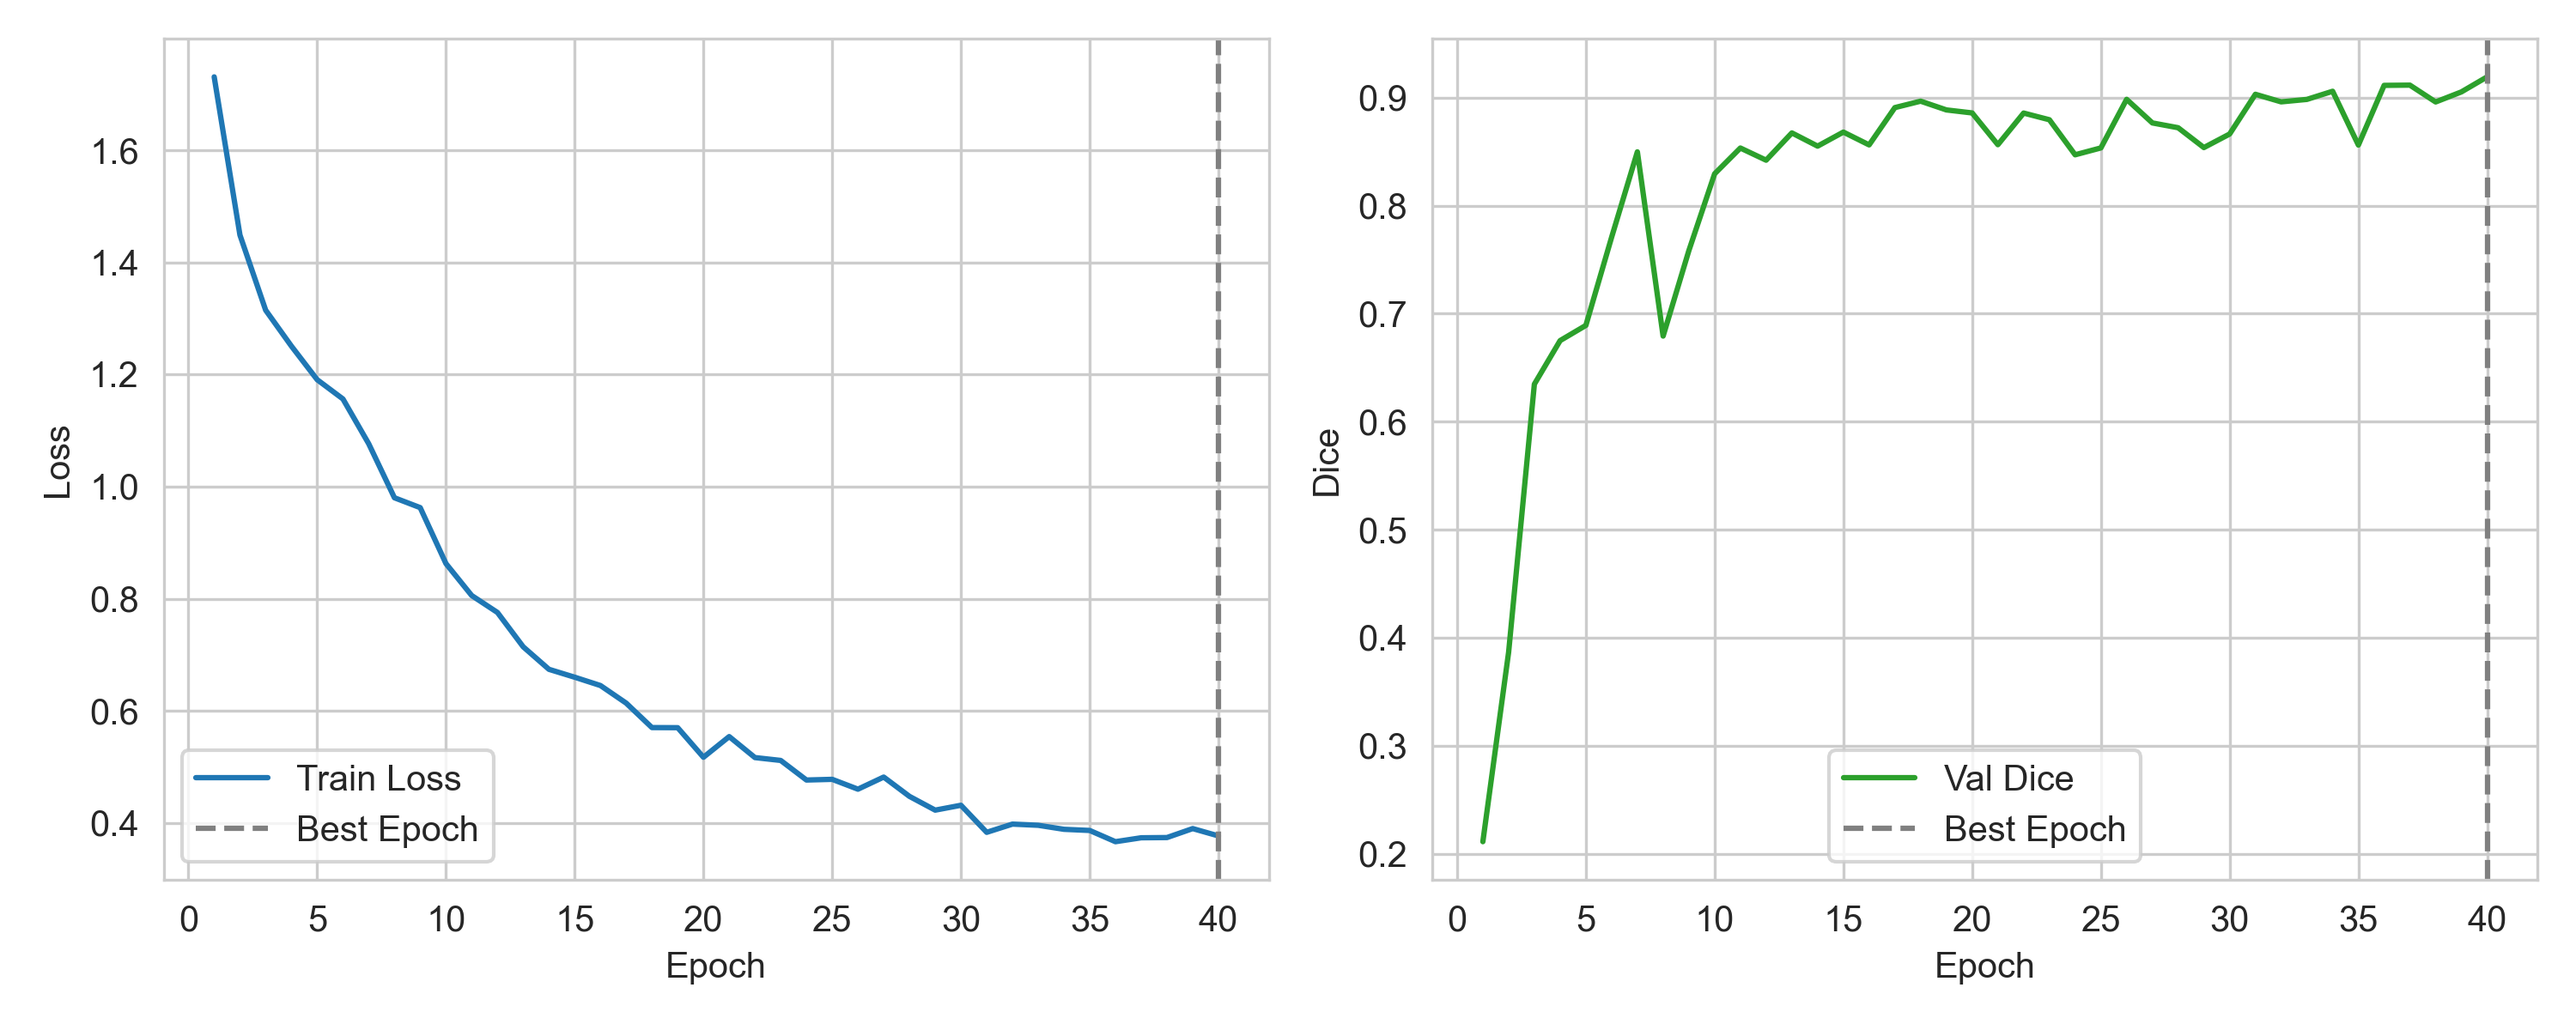

In [5]:
import sys, pathlib
sys.path.append(str(pathlib.Path('..').resolve()))
from src.predict_cac.segmentation.utils.visualization import plot_training_curves
history_path = pathlib.Path('..') / 'outputs' / 'metrics' / 'training_history.json'
fig_path = pathlib.Path('..') / 'outputs' / 'figures' / 'training_curves.png'
if history_path.exists():
    plot_training_curves(history_path, fig_path)
    from IPython.display import Image, display
    display(Image(filename=fig_path))
else:
    print('training_history.json not found; run training first')

Best validation Dice of X.XXX achieved at epoch N (filled after training).

## Section 3: Segmentation Results

In [6]:
per_case_path = pathlib.Path('..') / 'outputs' / 'metrics' / 'per_case_metrics.csv'
if per_case_path.exists():
    per_case_df = pd.read_csv(per_case_path)
    display(per_case_df)
else:
    print('per_case_metrics.csv not found')

,scan_id,dice,iou,hd95_mm,rve
0,patient_001.nii,0.813217,0.685228,1.210559,0.413251
1,patient_002.nii,0.844288,0.730535,0.640625,0.340294
2,patient_003.nii,0.858205,0.751628,1.099330,0.297119
3,patient_009.nii,0.781237,0.641008,2.515576,0.462425
4,patient_015.nii,0.893839,0.808055,0.917969,0.075909
5,patient_016.nii,0.872672,0.774107,1.365234,0.223142
6,patient_017.nii,0.825181,0.702390,0.738077,0.395928
7,patient_022.nii,0.823926,0.700574,3.673828,0.317430
8,patient_036.nii,0.839637,0.723598,0.869097,0.370548
9,patient_038.nii,0.819870,0.694729,1.049612,0.407064


In [7]:
summary_path = pathlib.Path('..') / 'outputs' / 'metrics' / 'summary_metrics.json'
if summary_path.exists():
    with open(summary_path, 'r', encoding='utf-8') as f:
        summary_metrics = json.load(f)
    display(pd.DataFrame(summary_metrics))
else:
    print('summary_metrics.json not found')

,dice,iou,hd95_mm,rve
mean,0.832559,0.714288,1.646912,0.337694
std,0.030028,0.044295,1.499758,0.119157
median,0.825181,0.702390,1.099330,0.370548
min,0.781237,0.641008,0.632812,0.075909
max,0.893839,0.808055,6.779398,0.503553


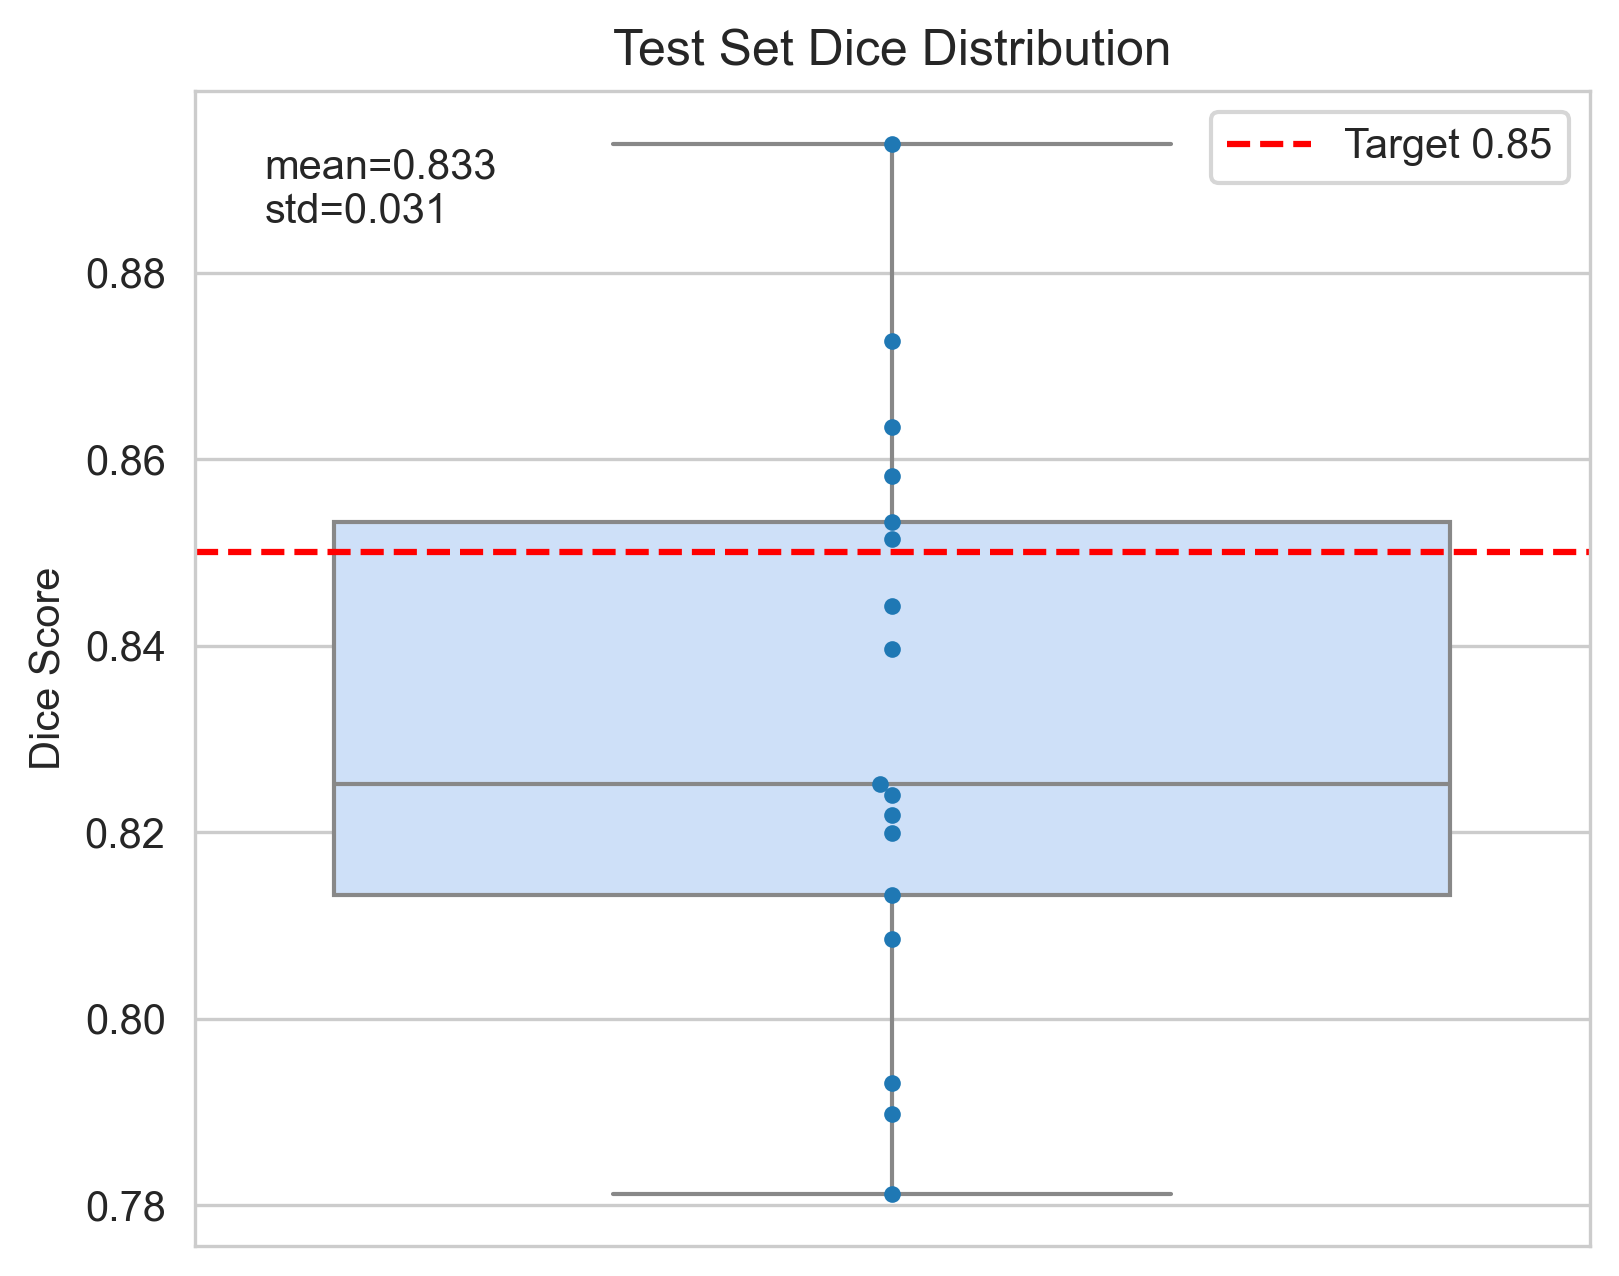

In [8]:
from src.predict_cac.segmentation.utils.visualization import plot_dice_distribution
fig_path = pathlib.Path('..') / 'outputs' / 'figures' / 'dice_distribution.png'
if per_case_path.exists():
    plot_dice_distribution(per_case_df, fig_path)
    from IPython.display import Image, display
    display(Image(filename=fig_path))

Dice scores are compared against the >0.85 target; see distribution above. The small test set caution applies here as well.

## Section 4: Visualizations (best/median/worst)

In [9]:
from src.predict_cac.segmentation.utils.visualization import plot_segmentation_overlay
from src.predict_cac.utils.config_loader import load_config
import pathlib

config = load_config(pathlib.Path('..') / 'config.yaml')
label_dir = pathlib.Path(config['data']['label_dir'])
pred_dir = pathlib.Path(config['outputs']['metrics_dir']) / 'pred_masks'
ct_dir = pathlib.Path(config['data']['image_dir'])

if per_case_path.exists():
    ordered = per_case_df.sort_values('dice')
    cases = {
        'worst': ordered.iloc[0],
        'median': ordered.iloc[len(ordered)//2],
        'best': ordered.iloc[-1],
    }
    for tag, row in cases.items():
        scan_id = row['scan_id']
        ct_path = ct_dir / f"{scan_id}.nii.gz"
        gt_path = label_dir / f"{scan_id}_heart_mask.nii.gz"
        pred_path = pred_dir / f"{scan_id}_pred_mask.nii.gz"
        save_path = pathlib.Path('..') / 'outputs' / 'figures' / f"{tag}_{scan_id}_overlay.png"
        if ct_path.exists() and gt_path.exists() and pred_path.exists():
            plot_segmentation_overlay(str(ct_path), str(gt_path), str(pred_path), scan_id, row['dice'], save_path)
            from IPython.display import Image, display
            display(Image(filename=save_path))
        else:
            print(f"Missing files for {scan_id}: ct={ct_path.exists()}, gt={gt_path.exists()}, pred={pred_path.exists()}")
else:
    print('per_case_metrics.csv not found; run evaluation first')

Missing files for patient_009.nii: ct=False, gt=False, pred=False
Missing files for patient_017.nii: ct=False, gt=False, pred=False
Missing files for patient_015.nii: ct=False, gt=False, pred=False


Interpret the best/median/worst overlays: look for boundary alignment, FP ribs/spine, and any missing chambers.

## Section 5: Failure Analysis

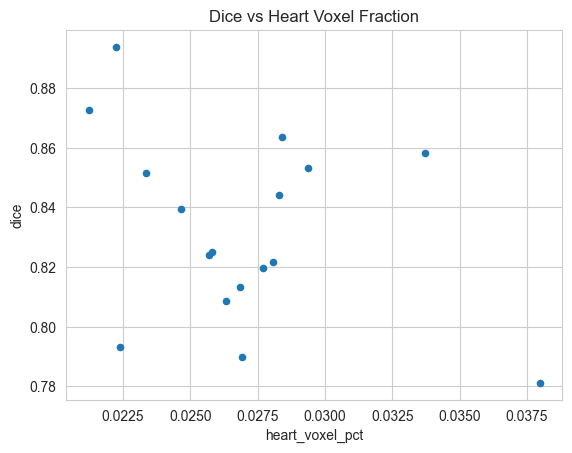

In [10]:
if per_case_path.exists() and dataset_stats_path.exists():
    merged = per_case_df.merge(dataset_stats[['scan_id','heart_voxel_pct']], on='scan_id', how='left')
    merged.plot.scatter(x='heart_voxel_pct', y='dice', title='Dice vs Heart Voxel Fraction')
else:
    print('Need per_case_metrics.csv and dataset_stats.csv for scatter plot')

Review worst cases for motion blur, truncated FOV, low contrast, or label QC misses. Note any correlation between heart size and Dice to guide future improvements.

## Section 6: Inference Benchmark

In [11]:
benchmark_path = pathlib.Path('..') / 'outputs' / 'metrics' / 'benchmark_results.csv'
if benchmark_path.exists():
    benchmark_df = pd.read_csv(benchmark_path)
    display(benchmark_df)
    display(benchmark_df.describe())
else:
    print('benchmark_results.csv not found; run benchmark_inference.py')

,scan_id,ts_time_s,model_time_s,speedup_x,dice
0,patient_001.nii,61.496101,0.227752,270.013678,0.809044
1,patient_002.nii,57.503600,0.173690,331.071060,0.831322
2,patient_003.nii,62.071256,0.228549,271.587919,0.850794
3,patient_009.nii,59.399431,0.232504,255.476480,0.772598
4,patient_015.nii,61.776199,0.159959,386.201172,0.887847
5,patient_016.nii,61.750440,0.161495,382.367270,0.863237
6,patient_017.nii,57.764436,0.167831,344.181956,0.797669
7,patient_022.nii,61.935921,0.185864,333.231937,0.811562
8,patient_036.nii,61.310443,0.142859,429.166317,0.846327
9,patient_038.nii,59.795910,0.171133,349.412331,0.812781


,ts_time_s,model_time_s,speedup_x,dice
count,17.000000,17.000000,17.000000,17.000000
mean,61.207504,0.185871,337.196638,0.823910
std,4.072014,0.029915,57.871806,0.030074
min,57.503600,0.142859,247.613396,0.772598
25%,59.161452,0.166019,296.516197,0.800167
50%,61.047804,0.173690,333.231937,0.820216
75%,61.776199,0.211152,366.339378,0.842613
max,75.721907,0.238927,456.104138,0.887847


Fair comparison protocol: identical input spacing (2.5mm), batch size 1, two warmup runs, model-only and full pipeline timing, same GPU/CPU hardware and session, TotalSegmentator v2 heartchambers_highres vs lightweight 3D U-Net.

## Section 7: CAC Masking Demonstration

In [12]:
from src.predict_cac.segmentation.utils.visualization import plot_cac_masking_demo
import pathlib

reductions = []
if pred_dir.exists():
    for pred_path in sorted(pred_dir.glob('*_pred_mask.nii.gz'))[:5]:
        scan_id = pred_path.stem.replace('_pred_mask', '')
        ct_path = ct_dir / f"{scan_id}.nii.gz"
        if ct_path.exists():
            save_path = pathlib.Path('..') / 'outputs' / 'figures' / f"{scan_id}_cac_masking.png"
            reduction = plot_cac_masking_demo(str(ct_path), str(pred_path), scan_id, save_path)
            reductions.append(reduction)
    if reductions:
        mean_reduction = sum(reductions) / len(reductions)
        print(f"Mean FP reduction across {len(reductions)} cases: {mean_reduction:.1f}%")
    else:
        print('No matching CTs found for predicted masks')
else:
    print('No predicted masks found in pred_dir; run inference first')

No predicted masks found in pred_dir; run inference first


Applying the heart mask suppresses rib/spine false positives for CAC scoring, making HU>130 detection cardiac-specific.

## Section 8: Limitations & Future Work
- Small test set (N=5–7) limits statistical confidence.
- Pseudo-ground truth from TotalSegmentator, not human annotation.
- 2.5mm resolution may miss fine structures.
- Next: use heart ROI as localization prior for CAC-specific segmentation and Agatston scoring.